In [1]:
"""
Portfolio Risk Attribution — Nifty50 (2020–2025)
Euler Decomposition: Volatility & CVaR
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Style ──────────────────────────────────────────────────────────────────────

DARK_BG = "#0D1117";  CARD_BG = "#161B22";  BORDER = "#30363D"
ACCENT  = ["#58A6FF","#3FB950","#F78166","#D2A8FF","#FFA657",
           "#79C0FF","#56D364","#FF7B72","#BC8CFF","#FFD28A"]
TEXT_PRI = "#E6EDF3";  TEXT_SEC = "#8B949E"

plt.rcParams.update({
    "figure.facecolor": DARK_BG,  "axes.facecolor": CARD_BG,
    "axes.edgecolor":   BORDER,   "axes.labelcolor": TEXT_PRI,
    "axes.titlecolor":  TEXT_PRI, "xtick.color": TEXT_SEC,
    "ytick.color":      TEXT_SEC, "text.color":  TEXT_PRI,
    "grid.color":       BORDER,   "grid.linewidth": 0.6,
    "font.family":      "DejaVu Sans", "font.size": 10,
    "legend.facecolor": CARD_BG,  "legend.edgecolor": BORDER,
})


In [2]:
# ── Stock universe ─────────────────────────────────────────────────────────────

STOCKS  = ["Reliance","TCS","HDFC Bank","Infosys","ICICI Bank",
           "Kotak Bank","L&T","Axis Bank","Wipro","Sun Pharma"]
TICKERS = ["RELIANCE.NS","TCS.NS","HDFCBANK.NS","INFY.NS","ICICIBANK.NS",
           "KOTAKBANK.NS","LT.NS","AXISBANK.NS","WIPRO.NS","SUNPHARMA.NS"]
N = len(STOCKS)

# ── Data — swap the block below for live yfinance pull when running locally ────
import yfinance as yf
raw      = yf.download(TICKERS, start="2020-01-01", end="2025-01-01",
                       auto_adjust=True, progress=False)["Close"]
raw.columns = STOCKS; raw.ffill(inplace=True)
log_ret  = np.log(raw / raw.shift(1)).dropna()
prices   = raw


dates   = pd.bdate_range("2020-01-01", periods=1237)

In [3]:
# ── Covariance & equal-weight portfolio ────────────────────────────────────────

W        = np.ones(N) / N
COV      = np.cov(log_ret.values, rowvar=False)
port_ret = log_ret.values @ W
port_vol = float(np.sqrt(W @ COV @ W))

print(f"Annualised Portfolio Volatility: {port_vol * np.sqrt(252) * 100:.2f}%")

Annualised Portfolio Volatility: 20.05%


In [4]:
# ── Volatility Risk Contribution — Euler: RC_i = w_i * (Sw)_i / sigma_p ───────

mrc_vol    = (COV @ W) / port_vol
rc_vol     = W * mrc_vol
rc_pct_vol = rc_vol / port_vol * 100

vol_df = pd.DataFrame({"Weight (%)": W*100, "MRC (ann)": mrc_vol*np.sqrt(252),
                        "RC (%)": rc_pct_vol}, index=STOCKS)

print("\nVolatility RC")
print(vol_df.to_string(float_format="{:.2f}".format))
print(f"Sum of RC: {vol_df['RC (%)'].sum():.2f}%  ← must be 100%")


Volatility RC
            Weight (%)  MRC (ann)  RC (%)
Reliance         10.00       0.28   14.04
TCS              10.00       0.20   10.04
HDFC Bank        10.00       0.26   12.73
Infosys          10.00       0.19    9.43
ICICI Bank       10.00       0.21   10.26
Kotak Bank       10.00       0.20   10.17
L&T              10.00       0.20    9.89
Axis Bank        10.00       0.13    6.44
Wipro            10.00       0.16    7.92
Sun Pharma       10.00       0.18    9.08
Sum of RC: 100.00%  ← must be 100%


In [5]:
# ── CVaR Risk Contribution — conditional expectation in the tail ───────────────

ALPHA      = 0.05
var_thresh = np.percentile(port_ret, ALPHA * 100)
tail_mask  = port_ret <= var_thresh
exp_tail   = np.mean(log_ret.values[tail_mask], axis=0)
rc_cvar    = W * exp_tail
rc_pct_cvar = rc_cvar / rc_cvar.sum() * 100
port_cvar  = float(-np.mean(port_ret[tail_mask]) * np.sqrt(252) * 100)

cvar_df = pd.DataFrame({"Weight (%)": W*100, "Tail Mean Ret": exp_tail,
                         "RC (%)": rc_pct_cvar}, index=STOCKS)

print(f"\nCVaR RC  (alpha={ALPHA:.0%}, {tail_mask.sum()} tail days, port CVaR={port_cvar:.2f}%)")
print(cvar_df.to_string(float_format="{:.4f}".format))
print(f"Sum of RC: {cvar_df['RC (%)'].sum():.2f}%  <- must be 100%")


CVaR RC  (alpha=5%, 62 tail days, port CVaR=48.74%)
            Weight (%)  Tail Mean Ret  RC (%)
Reliance       10.0000        -0.0442 14.3870
TCS            10.0000        -0.0318 10.3576
HDFC Bank      10.0000        -0.0406 13.2216
Infosys        10.0000        -0.0264  8.6141
ICICI Bank     10.0000        -0.0345 11.2340
Kotak Bank     10.0000        -0.0321 10.4701
L&T            10.0000        -0.0301  9.7992
Axis Bank      10.0000        -0.0196  6.3793
Wipro          10.0000        -0.0221  7.1846
Sun Pharma     10.0000        -0.0256  8.3525
Sum of RC: 100.00%  <- must be 100%


In [6]:
# ── Annualised stats ───────────────────────────────────────────────────────────

ann_ret = log_ret.mean() * 252 * 100
ann_std = log_ret.std()  * np.sqrt(252) * 100
sharpe  = ann_ret / ann_std

stats_df = pd.DataFrame({"Ann Ret (%)": ann_ret, "Ann Vol (%)": ann_std,
                          "Sharpe": sharpe})
print("\nAnnualised Stats"); print(stats_df.round(2).to_string())


Annualised Stats
            Ann Ret (%)  Ann Vol (%)  Sharpe
Reliance           7.24        37.26    0.19
TCS                7.49        27.34    0.27
HDFC Bank         18.25        31.94    0.57
Infosys           21.58        27.85    0.77
ICICI Bank         1.38        29.48    0.05
Kotak Bank        22.37        28.92    0.77
L&T               11.89        29.68    0.40
Axis Bank         30.97        25.47    1.22
Wipro             14.95        24.47    0.61
Sun Pharma        18.57        29.08    0.64


In [7]:
# ── Rolling 60-day volatility contributions ────────────────────────────────────

WINDOW = 60
roll_rc = []
for t_ in range(WINDOW, len(log_ret)):
    chunk = log_ret.values[t_-WINDOW:t_]
    cov_t = np.cov(chunk, rowvar=False)
    pv_t  = np.sqrt(W @ cov_t @ W)
    roll_rc.append((W * (cov_t @ W) / pv_t) / pv_t * 100)

roll_df = pd.DataFrame(roll_rc, columns=STOCKS, index=dates[WINDOW:])
print(f"\nRolling contributions: {len(roll_df)} windows computed")


Rolling contributions: 1177 windows computed


In [8]:
# ── Correlation matrix ────────────────────────────────────────────────────────

corr_matrix = log_ret.corr()
print("\nTop correlated pairs:")
tri = corr_matrix.where(np.tril(np.ones_like(corr_matrix, dtype=bool), k=-1))
print(tri.stack().nlargest(3).round(3).to_string())


Top correlated pairs:
HDFC Bank  Reliance    0.757
Wipro      Infosys     0.710
HDFC Bank  TCS         0.643


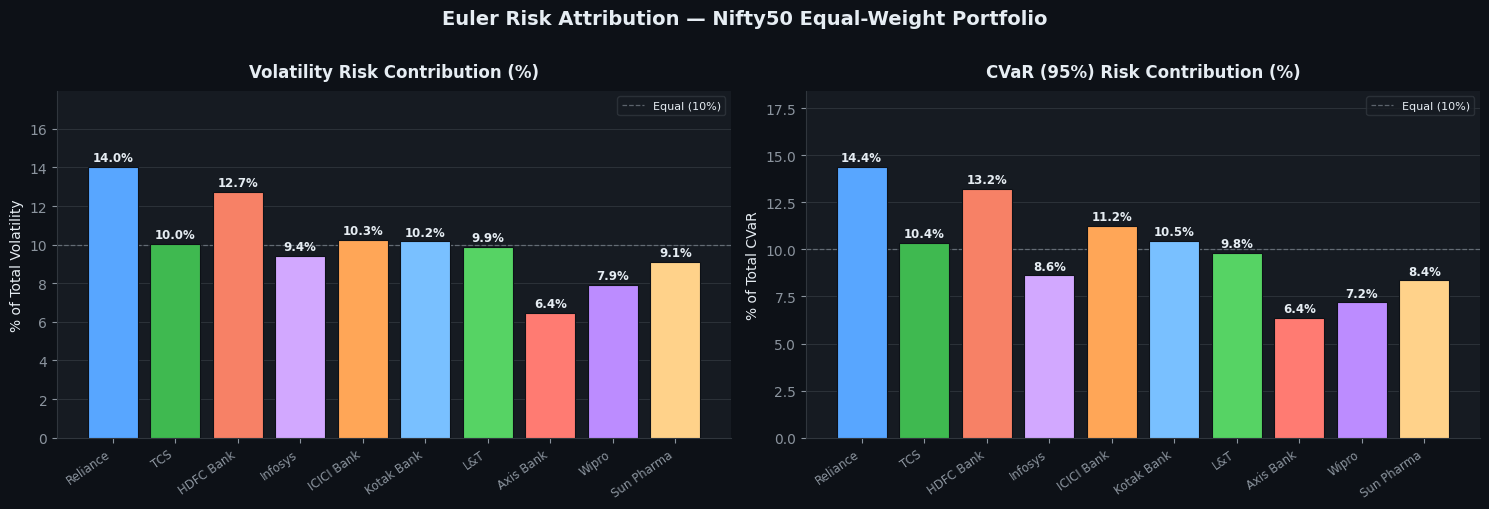

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 1 — Risk Contributions: Volatility & CVaR bars side by side
# ══════════════════════════════════════════════════════════════════════════════

fig1, (ax_v, ax_c) = plt.subplots(1, 2, figsize=(15, 5), facecolor=DARK_BG)
fig1.suptitle("Euler Risk Attribution — Nifty50 Equal-Weight Portfolio",
              fontsize=14, fontweight="bold", y=1.01)

for ax, df, title, ylabel in [
    (ax_v, vol_df,  "Volatility Risk Contribution (%)", "% of Total Volatility"),
    (ax_c, cvar_df, "CVaR (95%) Risk Contribution (%)", "% of Total CVaR"),
]:
    bars = ax.bar(STOCKS, df["RC (%)"], color=ACCENT, edgecolor=DARK_BG, lw=0.8, zorder=3)
    ax.axhline(10, color=TEXT_SEC, lw=0.9, ls="--", alpha=0.6, label="Equal (10%)")
    for b, v in zip(bars, df["RC (%)"]):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.15,
                f"{v:.1f}%", ha="center", va="bottom",
                fontsize=8.5, color=TEXT_PRI, fontweight="bold")
    ax.set_title(title, fontweight="bold", pad=10)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, df["RC (%)"].max() * 1.28)
    ax.set_xticks(range(N)); ax.set_xticklabels(STOCKS, rotation=35, ha="right", fontsize=8.5)
    ax.grid(axis="y", zorder=0); ax.spines[["top","right"]].set_visible(False)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

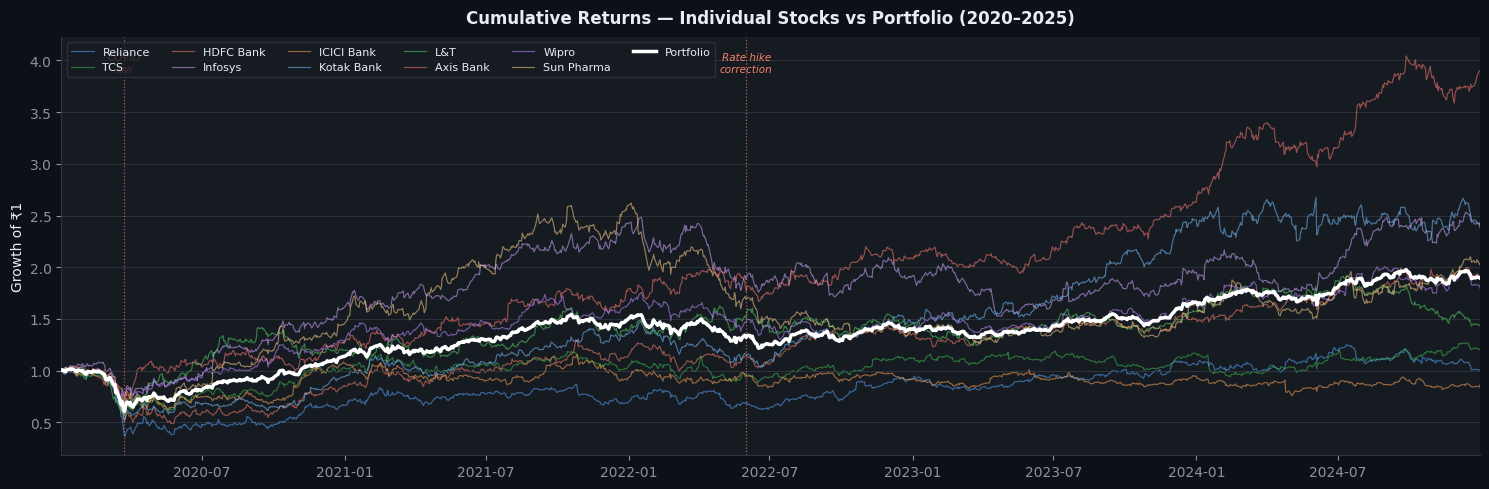

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 2 — Cumulative Returns with regime annotations
# ══════════════════════════════════════════════════════════════════════════════

cum      = (1 + log_ret).cumprod()
port_cum = (cum * W).sum(axis=1)

fig2, ax = plt.subplots(figsize=(15, 5), facecolor=DARK_BG)
for i, col in enumerate(STOCKS):
    ax.plot(cum.index, cum[col], color=ACCENT[i], lw=0.85, alpha=0.55, label=col)
ax.plot(port_cum.index, port_cum, color="white", lw=2.5, label="Portfolio", zorder=10)
ax.axhline(1.0, color=BORDER, lw=0.7, ls="--")

for x, lbl in [("2020-03-23","COVID\nlow"), ("2022-06-01","Rate hike\ncorrection")]:
    ax.axvline(pd.Timestamp(x), color=ACCENT[2], lw=0.9, ls=":", alpha=0.7)
    ax.text(pd.Timestamp(x), ax.get_ylim()[1]*0.92, lbl,
            ha="center", fontsize=7.5, color=ACCENT[2], style="italic")

ax.set_title("Cumulative Returns — Individual Stocks vs Portfolio (2020–2025)",
             fontweight="bold", pad=10)
ax.set_ylabel("Growth of ₹1"); ax.set_xlim(cum.index[0], cum.index[-1])
ax.legend(ncol=6, fontsize=8, loc="upper left", framealpha=0.8)
ax.grid(axis="y", zorder=0); ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

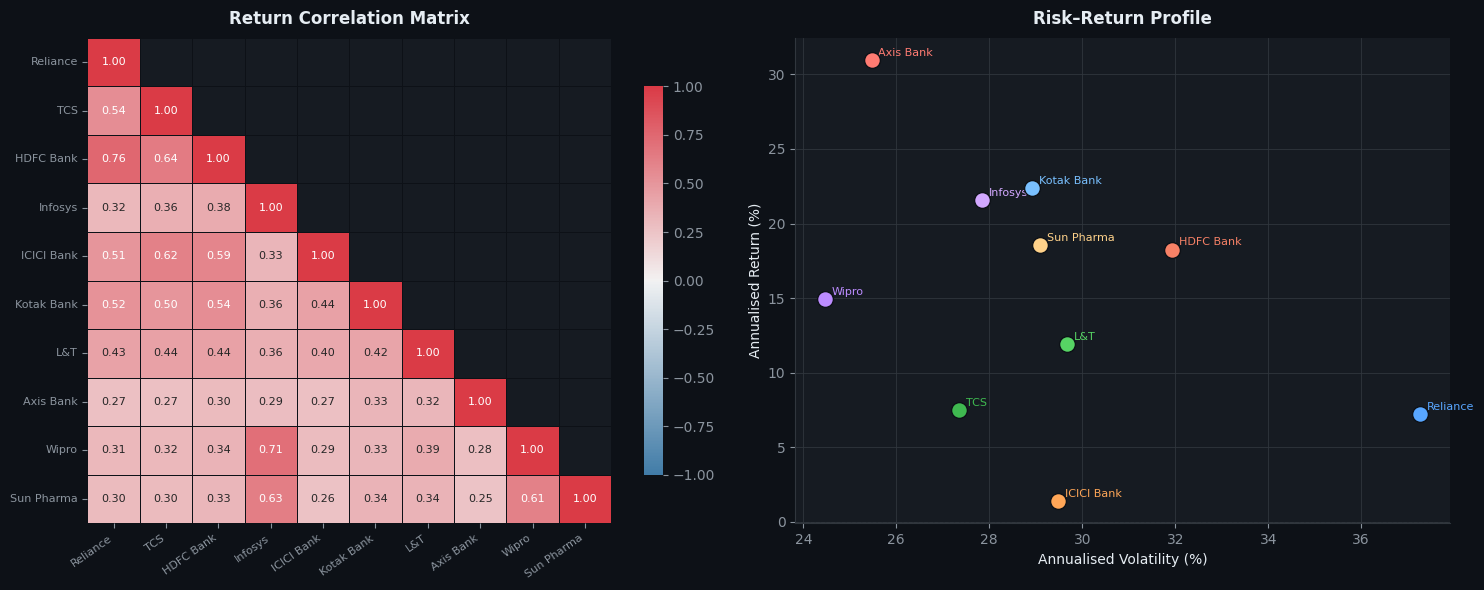

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 3 — Correlation heatmap + Risk-Return scatter
# ══════════════════════════════════════════════════════════════════════════════

fig3, (ax_h, ax_s) = plt.subplots(1, 2, figsize=(15, 6), facecolor=DARK_BG)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, ax=ax_h, mask=mask,
            cmap=sns.diverging_palette(240, 10, as_cmap=True),
            vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 8}, linewidths=0.5, linecolor=DARK_BG,
            cbar_kws={"shrink": 0.8})
ax_h.set_title("Return Correlation Matrix", fontweight="bold", pad=10)
ax_h.set_xticklabels(ax_h.get_xticklabels(), rotation=35, ha="right", fontsize=8)
ax_h.set_yticklabels(ax_h.get_yticklabels(), rotation=0, fontsize=8)

for i, s in enumerate(STOCKS):
    ax_s.scatter(ann_std[s], ann_ret[s], color=ACCENT[i],
                 s=130, zorder=5, edgecolors=DARK_BG, lw=1)
    ax_s.annotate(s, (ann_std[s], ann_ret[s]),
                  textcoords="offset points", xytext=(5, 3),
                  fontsize=8, color=ACCENT[i])
ax_s.axhline(0, color=BORDER, lw=0.7, ls="--")
ax_s.set_xlabel("Annualised Volatility (%)"); ax_s.set_ylabel("Annualised Return (%)")
ax_s.set_title("Risk–Return Profile", fontweight="bold", pad=10)
ax_s.grid(zorder=0); ax_s.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

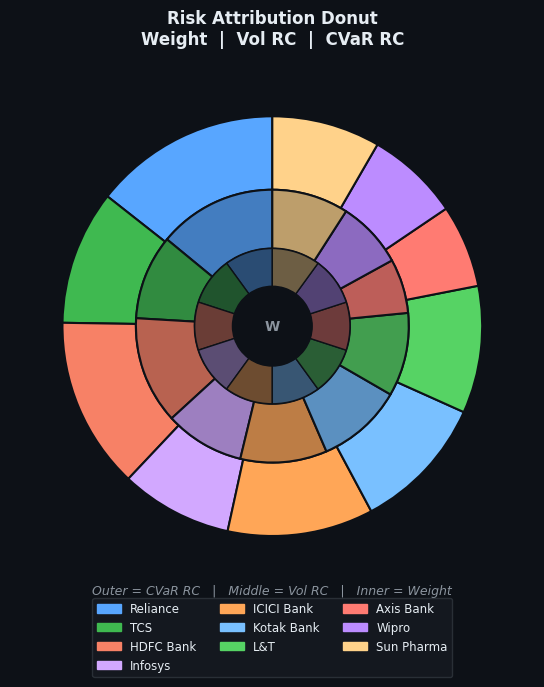

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 4 — Concentric donut: Weight / Vol RC / CVaR RC
# ══════════════════════════════════════════════════════════════════════════════

fig4, ax = plt.subplots(figsize=(8, 7), facecolor=DARK_BG)

ax.pie(cvar_df["RC (%)"].abs(), radius=1.0, colors=ACCENT,
       wedgeprops=dict(width=0.35, edgecolor=DARK_BG, lw=1.5), startangle=90)
ax.pie(vol_df["RC (%)"].abs(),  radius=0.65, colors=[c+"BB" for c in ACCENT],
       wedgeprops=dict(width=0.28, edgecolor=DARK_BG, lw=1.5), startangle=90)
ax.pie(W * 100, radius=0.37, colors=[c+"66" for c in ACCENT],
       wedgeprops=dict(width=0.18, edgecolor=DARK_BG, lw=1.0), startangle=90)
ax.text(0, 0, "W", ha="center", va="center", fontsize=10, color=TEXT_SEC, fontweight="bold")
ax.text(0, -1.28, "Outer = CVaR RC   |   Middle = Vol RC   |   Inner = Weight",
        ha="center", fontsize=9, color=TEXT_SEC, style="italic")

patches = [mpatches.Patch(color=c, label=s) for c, s in zip(ACCENT, STOCKS)]
ax.legend(handles=patches, loc="lower center", bbox_to_anchor=(0.5, -0.18),
          ncol=3, fontsize=8.5, framealpha=0.8)
ax.set_title("Risk Attribution Donut\nWeight  |  Vol RC  |  CVaR RC",
             fontweight="bold", pad=14)
plt.tight_layout()
plt.show()

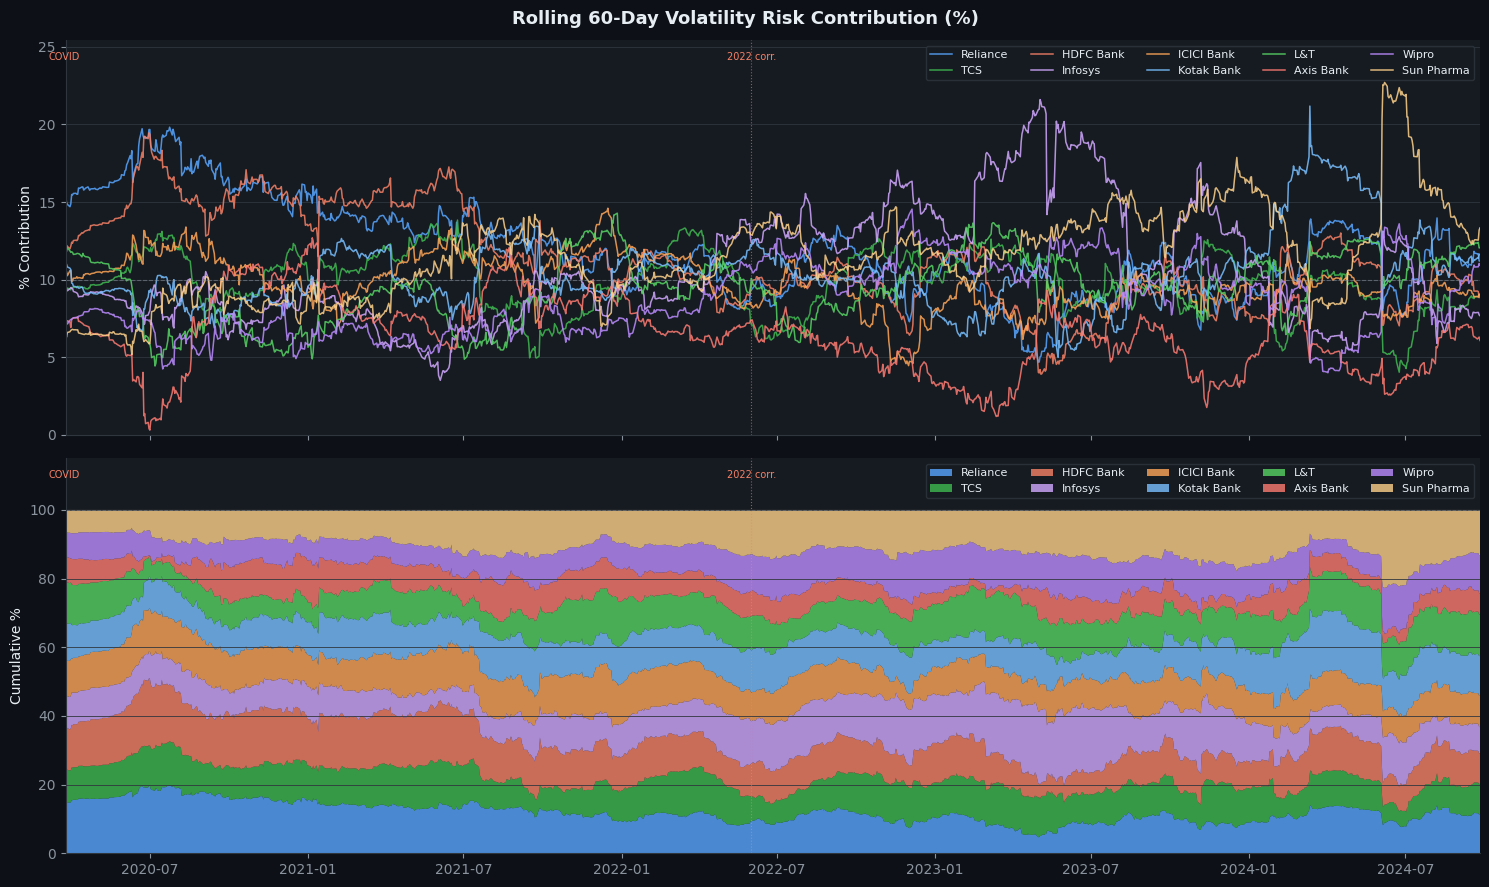

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# PLOT 5 — Rolling 60-day Vol RC: line chart + stacked area
# ══════════════════════════════════════════════════════════════════════════════

fig5, (ax_l, ax_st) = plt.subplots(2, 1, figsize=(15, 9),
                                    facecolor=DARK_BG, sharex=True)
fig5.suptitle("Rolling 60-Day Volatility Risk Contribution (%)",
              fontsize=13, fontweight="bold")

for i, s in enumerate(STOCKS):
    ax_l.plot(roll_df.index, roll_df[s], color=ACCENT[i], lw=1.1, label=s, alpha=0.85)
ax_l.axhline(10, color=TEXT_SEC, lw=0.8, ls="--", alpha=0.5)
ax_l.set_ylabel("% Contribution"); ax_l.set_ylim(0, roll_df.values.max() * 1.12)
ax_l.legend(ncol=5, fontsize=8, loc="upper right", framealpha=0.8)
ax_l.grid(axis="y", zorder=0); ax_l.spines[["top","right"]].set_visible(False)

ax_st.stackplot(roll_df.index, roll_df.T, labels=STOCKS, colors=ACCENT, alpha=0.8)
ax_st.axhline(100, color=TEXT_SEC, lw=0.7, ls="--", alpha=0.4)
ax_st.set_ylabel("Cumulative %"); ax_st.set_ylim(0, 115)
ax_st.set_xlim(roll_df.index[0], roll_df.index[-1])
ax_st.legend(ncol=5, fontsize=8, loc="upper right", framealpha=0.8)
ax_st.grid(axis="y", zorder=0); ax_st.spines[["top","right"]].set_visible(False)

for ax_ in (ax_l, ax_st):
    for x, lbl in [("2020-03-23","COVID"), ("2022-06-01","2022 corr.")]:
        ax_.axvline(pd.Timestamp(x), color=ACCENT[2], lw=0.8, ls=":", alpha=0.6)
        ax_.text(pd.Timestamp(x), ax_.get_ylim()[1]*0.95, lbl,
                 ha="center", fontsize=7, color=ACCENT[2])

plt.tight_layout()
plt.show()